# Premier essaie de génération d'images

In [6]:
# Suppression des warnings FutureWarning
import warnings  # Gère les warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Librairies générales
import pandas as pd  # Manipulation de données tabulaires
import numpy as np  # Calcul scientifique et manipulation de matrices
import os  # Interaction avec le système de fichiers
from os.path import isfile, join  # Fonctions de gestion des chemins de fichiers
import sys  # Interaction avec l'interpréteur Python
import random  # Génération de nombres aléatoiresr
import zipfile  # Manipulation d'archives zip
from scipy.stats import norm, entropy # Statistiques sur les données

# Librairie d'affichage
import matplotlib.pyplot as plt  # Visualisation de données
from matplotlib.offsetbox import OffsetImage, AnnotationBbox  # Visualisation de données
from PIL import Image, ImageDraw  # Traitement d'images avec Pillow

# Bibliothèque scikit-learn
from sklearn.decomposition import PCA  # Réduction de dimension
from sklearn.manifold import TSNE  # Visualisation de données en dimension réduite

# TensorFlow et Keras
import tensorflow as tf  # API principale de TensorFlow
from tensorflow.keras.losses import mse  # Perte par erreur quadratique moyenne
from keras import layers, models, optimizers  # Création et gestion des modèles
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Générateur
from keras.preprocessing.image import img_to_array, load_img, array_to_img  # Préparation et transformation des images
from keras.callbacks import ModelCheckpoint, EarlyStopping  # Gestion des callbacks pour l'entraînement
from keras.layers import (Input, Conv2D, Flatten, Dense, Conv2DTranspose, Reshape,
                           Lambda, Activation, BatchNormalization, LeakyReLU, Dropout,
                           MaxPooling2D, UpSampling2D)  # Différentes couches pour les modèles CNN
from keras.optimizers import Adam  # Optimiseur Adam
from keras.models import Model, load_model  # Définition et chargement des modèles Keras
from keras.layers import LeakyReLU  # Activation LeakyReLU
import tensorflow.keras.backend as K # Import des opérations bas niveau de Keras

In [7]:
# Définition du répertoire cible
model_dir = "./Data_humanface_cat_without_caption_1000/"

# Création du répertoire s'il n'existe pas
os.makedirs(model_dir, exist_ok=True)

zip_file = "Data_humanface_cat_without_caption_1000.zip"

!wget https://www.lirmm.fr/~poncelet/Ressources/Data_humanface_cat_without_caption_1000.zip


# Extraction du fichier ZIP
with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(model_dir)

# Suppression du fichier ZIP après extraction pour économiser de l'espace
os.remove(zip_file)

--2026-05-03 13:42:38--  https://www.lirmm.fr/~poncelet/Ressources/Data_humanface_cat_without_caption_1000.zip
Resolving www.lirmm.fr (www.lirmm.fr)... 193.49.104.251
Connecting to www.lirmm.fr (www.lirmm.fr)|193.49.104.251|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 42306490 (40M) [application/zip]
Saving to: ‘Data_humanface_cat_without_caption_1000.zip’

Data_humanface_cat_ 100%[===================>]  40.35M   972KB/s    in 55s     

2026-05-03 13:43:31 (751 KB/s) - ‘Data_humanface_cat_without_caption_1000.zip’ saved [42306490/42306490]



In [8]:
##affichage des images 

Nombre d'images dans Data_humanface_cat_without_caption_1000/images/cat : 1000
Format (shape) des images : (256, 256, 3)


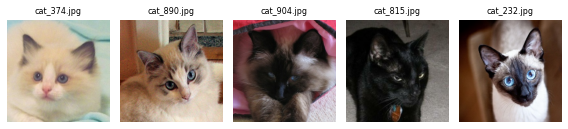

In [9]:
# Répertoire contenant les images
src_dir = "Data_humanface_cat_without_caption_1000/images"
image_dir = os.path.join(src_dir, "cat")

files = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]

print("Nombre d'images dans", image_dir, ":", len(files))

if files:
    with Image.open(os.path.join(image_dir, files[0])) as img:
        shape = img.size[::-1] + (3,)  # (height, width, 3)
        print("Format (shape) des images :", shape)


# Tirage de 5 images aléatoires
random_files = random.sample(files, 5)

# Affichage
plt.figure(figsize=(8, 2))
for i, fname in enumerate(random_files):
    img_path = os.path.join(image_dir, fname)
    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(fname, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
image_size = (128, 128, 3)  # Dimensions des images (hauteur, largeur, canaux)
batch_size = 512             # Taille des lots
latent_dim = 200             # Dimension du vecteur latent pour l'autoencodeur

# Génération des données normalisées (valeurs entre 0 et 1)
data_flow = ImageDataGenerator(rescale=1./255).flow_from_directory(
    directory=src_dir,
    classes=["cat"],  # Le sous-dossier contenant toutes les images
    target_size=image_size[:2],  # Redimension à 128x128
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    class_mode='input'  # Autoencodeur : entrée = sortie
)

Found 1000 images belonging to 1 classes.


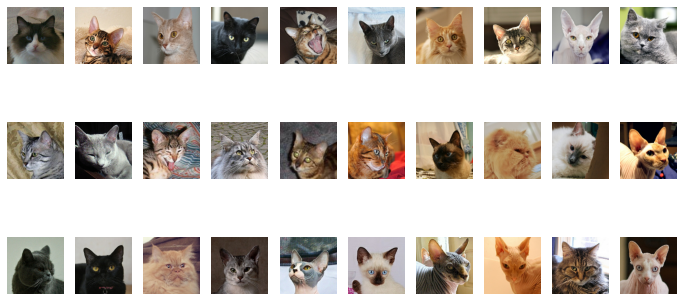

In [11]:
# Obtention du premier batch d'images générées
data_batch = next(data_flow)

# Affichage des 30 premières images du batch
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 10, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(data_batch[0][i])
    ax.axis('off')
plt.show()

In [12]:
def build_encoder(input_dim, output_dim):
    tf.keras.backend.clear_session()

    encoder_input = Input(shape=input_dim, name='encoder_input')
    x = encoder_input

    x = Conv2D(32, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_1')(x)
    x = LeakyReLU(name='encoder_act_1')(x)

    x = Conv2D(64, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_2')(x)
    x = LeakyReLU(name='encoder_act_2')(x)

    x = Conv2D(64, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_3')(x)
    x = LeakyReLU(name='encoder_act_3')(x)

    x = Conv2D(64, kernel_size=3, strides=2, padding='same',
               name='encoder_conv_4')(x)
    x = LeakyReLU(name='encoder_act_4')(x)

    shape_before_flattening = tf.keras.backend.int_shape(x)[1:]
    x = Flatten()(x)
    encoder_output = Dense(output_dim, name='encoder_output')(x)

    encoder = Model(encoder_input, encoder_output, name='encoder')
    return encoder_input, encoder_output, shape_before_flattening, encoder

def build_decoder(input_dim, shape_before_flattening):
    # Entrée du décodeur (vecteur latent)
    decoder_input = Input(shape=(input_dim,), name='decoder_input')

    # Projeter dans un tenseur de même forme qu'avant le Flatten de l'encodeur
    x = Dense(np.prod(shape_before_flattening))(decoder_input)
    x = Reshape(shape_before_flattening)(x)

    # Couches de déconvolution (effet miroir de l'encodeur)
    x = Conv2DTranspose(64, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_1')(x)
    x = LeakyReLU(name='decoder_act_1')(x)

    x = Conv2DTranspose(64, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_2')(x)
    x = LeakyReLU(name='decoder_act_2')(x)

    x = Conv2DTranspose(32, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_3')(x)
    x = LeakyReLU(name='decoder_act_3')(x)

    x = Conv2DTranspose(3, kernel_size=3, strides=2, padding='same',
                        name='decoder_conv_4')(x)
    decoder_output = Activation('sigmoid', name='decoder_output')(x)

    decoder = Model(decoder_input, decoder_output, name='decoder')
    return decoder_input, decoder_output, decoder

In [13]:
image_size = (128, 128, 3)  # Dimensions des images (hauteur, largeur, canaux)
batch_size = 512             # Taille des lots
latent_dim = 200             # Dimension du vecteur latent pour l'autoencodeur

# Création de l'encodeur avec les dimensions d'entrée et de sortie spécifiées
encoder_input, encoder_output, shape_before_flattening, encoder = build_encoder(
    input_dim=image_size,
    output_dim=latent_dim
)

# Création du décodeur en utilisant la dimension de l'espace latent
# et le shape  avant le flattening
decoder_input, decoder_output, decoder = build_decoder(
    input_dim=latent_dim,
    shape_before_flattening=shape_before_flattening
)


2026-05-03 13:43:46.610610: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
# L'entrée du modèle autoencodeur est celle de l'encodeur
autoencoder_input = encoder_input

# La sortie est obtenue en appliquant le décodeur à la sortie de l'encodeur
autoencoder_output = decoder(encoder_output)

# Création du modèle autoencodeur complet (encodeur + décodeur)
autoencoder = Model(autoencoder_input, autoencoder_output, name='autoencoder')

# Affichage de la structure du modèle
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_1 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_4 (Conv2D)         │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_act_4 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_output (Dense)          │ (None, 200)            │       819,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 3)    │       916,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,829,131 (6.98 MB)

 Trainable params: 1,829,131 (6.98 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Génération des données normalisées (valeurs entre 0 et 1)
data_flow = ImageDataGenerator(rescale=1./255).flow_from_directory(
    directory=src_dir,
    classes=['cat'],  # Le sous-dossier contenant toutes les images
    target_size=image_size[:2],  # Redimension à 128x128
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    class_mode='input'  # Autoencodeur : entrée = sortie
)

Found 1000 images belonging to 1 classes.


Espace latent

In [16]:
def visualize_latent_space(encoder_model, images, num_images=100,
                           image_size=(28, 28), zoom=0.6):
    """
    Visualise la répartition de l'espace latent en utilisant t-SNE
    et affiche des vignettes d'images.

    Paramètres :
    -----------
    encoder_model : Model
        Le modèle d'encodeur (autoencodeur ou VAE) à utiliser pour obtenir
        les vecteurs latents.
    images : array-like
        Batch d'images d'entrée pour la visualisation.
    num_images : int, optional
        Nombre d'images à utiliser pour la visualisation (par défaut 100).
    image_size : tuple, optional
        Taille des vignettes d'image à afficher (par défaut (28, 28)).
    zoom : float, optional
        Facteur de zoom pour les vignettes d'image (par défaut 0.6).
    """
    # Limite le nombre d'images à `num_images`
    images = images[:num_images]

    # Génère les vecteurs latents avec l'encodeur
    latent_vectors = encoder_model.predict(images)
    if isinstance(latent_vectors, list):
        latent_vectors = latent_vectors[0]

    # Aplatit les vecteurs latents s'ils ont plus de 2 dimensions
    if latent_vectors.ndim > 2:
        latent_vectors = latent_vectors.reshape((latent_vectors.shape[0], -1))

    # Réduction de dimension avec t-SNE pour projeter en 2D
    tsne = TSNE(n_components=2, random_state=42)
    latent_2d = tsne.fit_transform(latent_vectors)

    plt.figure(figsize=(15, 12))
    ax = plt.gca()

    # Affichage des images dans l'espace t-SNE avec AnnotationBbox
    for i, (x, y) in enumerate(latent_2d):
        # Conversion de l'image en vignette
        thumbnail = array_to_img(images[i])
        thumbnail = thumbnail.resize(image_size)
        imagebox = OffsetImage(thumbnail, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False)
        ax.add_artist(ab)

    all_x, all_y = latent_2d[:, 0], latent_2d[:, 1]
    ax.set_xlim(all_x.min() - 5, all_x.max() + 5)
    ax.set_ylim(all_y.min() - 5, all_y.max() + 5)

    plt.title("Répartition des images dans l'espace latent")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")

    ax.grid(False)
    plt.show()

In [17]:
#my guess is we need this before?
# Définition des hyperparamètres
epochs = 150
model_name = "catmodeltrain.keras"
model_path = os.path.join(model_dir, model_name)

# Compilation du modèle autoencodeur
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Générateur principal avec normalisation  et séparation train/validation
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Générateur pour les données d'entraînement
train_flow = train_gen.flow_from_directory(
    directory=src_dir,
    classes=['cat'],  # le sous-dossier contenant toutes les images
    target_size=image_size[:2],
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    class_mode='input',
    subset='training'
)

# Générateur pour les données de validation
val_flow = train_gen.flow_from_directory(
    directory=src_dir,
    classes=['cat'],
    target_size=image_size[:2],
    batch_size=batch_size,
    shuffle=False,
    seed=42,
    class_mode='input',
    subset='validation'
)


# Entraînement du modèle autoencodeur
#autoencoder = train_autoencoder_from_generator(
   # model=autoencoder,
    #train_gen=train_flow,
    #val_gen=val_flow,
    #model_path=model_path,
    #epochs=epochs,
    #patience=5
#)

Found 800 images belonging to 1 classes.
Found 200 images belonging to 1 classes.


In [18]:
# Chemin vers le modèle entraîné
model_path = os.path.join(model_dir, "catmodeltrain.keras")

# Chargement du modèle
autoencoder = load_model(model_path)

# Récupération du premier lot d'images
example_batch = next(data_flow)

# Extraction des images
example_batch = example_batch[0]

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


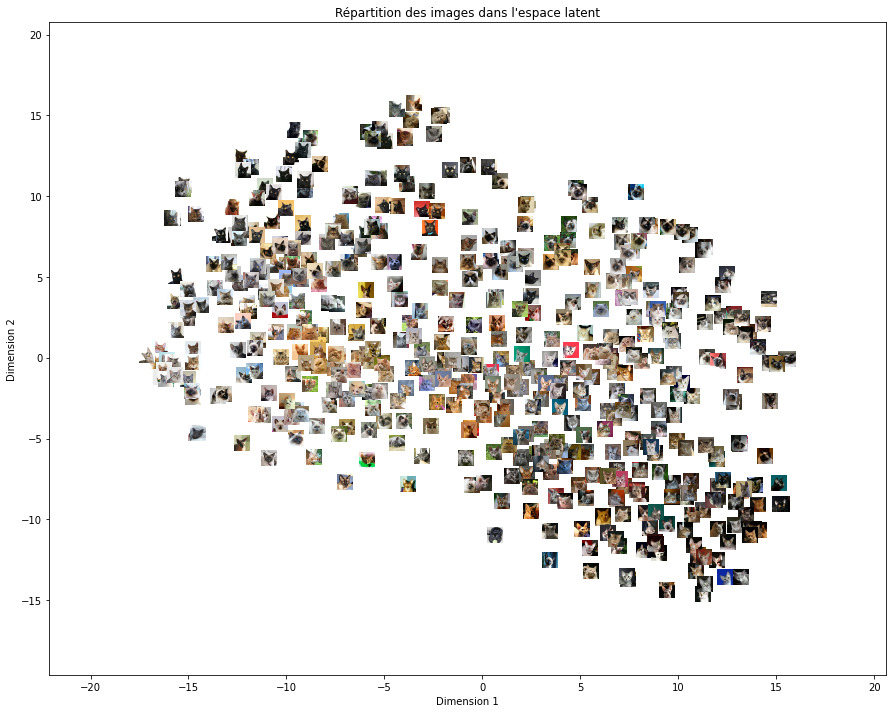

In [19]:
# Visualisation de l'espace latent avec les vignettes
visualize_latent_space(
    encoder_model=encoder,
    images=example_batch,
    num_images=batch_size,
    image_size=(32, 32),
    zoom=0.5
)

In [23]:
image_size = (128, 128, 3)  # Dimensions des images (hauteur, largeur, canaux)
batch_size = 512             # Taille des lots
latent_dim = 200             # Dimension du vecteur latent pour l'autoencodeur

In [24]:
import tensorflow as tf
# Fonction de sampling avec reparameterization trick
@tf.keras.utils.register_keras_serializable()
def sampling(args):
    mean_mu, log_var = args
    epsilon = K.random_normal(shape=K.shape(mean_mu), mean=0., stddev=1.)
    return mean_mu + K.exp(log_var / 2) * epsilon

# Couche personnalisée pour le calcul de la perte KL
@tf.keras.utils.register_keras_serializable()
class KLLossLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        mean_mu, log_var = inputs
        kl_loss = -0.5 * tf.reduce_sum(1 + log_var - tf.square(mean_mu) - tf.exp(log_var), axis=1)
        self.add_loss(kl_loss)
        return kl_loss

# VAE Encoder
def build_vae_encoder(input_dim, output_dim):
    tf.keras.backend.clear_session()

    vae_encoder_input = Input(shape=input_dim, name='vae_encoder_input')
    x = vae_encoder_input

    x = Conv2D(32, 3, strides=2, padding='same', name='vae_encoder_conv_1')(x)
    x = LeakyReLU(name='vae_encoder_act_1')(x)

    x = Conv2D(64, 3, strides=2, padding='same', name='vae_encoder_conv_2')(x)
    x = LeakyReLU(name='vae_encoder_act_2')(x)

    x = Conv2D(64, 3, strides=2, padding='same', name='vae_encoder_conv_3')(x)
    x = LeakyReLU(name='vae_encoder_act_3')(x)

    x = Conv2D(64, 3, strides=2, padding='same', name='vae_encoder_conv_4')(x)
    x = LeakyReLU(name='vae_encoder_act_4')(x)

    shape_before_flattening = tf.keras.backend.int_shape(x)[1:]
    x = Flatten(name='vae_encoder_flatten')(x)

    mean_mu = Dense(output_dim, name='mu')(x)
    log_var = Dense(output_dim, name='log_var')(x)

    vae_encoder_output = Lambda(sampling, output_shape=(output_dim,),
                                name='vae_encoder_output')([mean_mu, log_var])

    _ = KLLossLayer(name='kl_loss')([mean_mu, log_var])

    vae_encoder = Model(vae_encoder_input, vae_encoder_output, name='vae_encoder')
    return vae_encoder_input, vae_encoder_output, mean_mu, log_var, shape_before_flattening, vae_encoder

In [25]:
# Construction de l'encodeur VAE
vae_encoder_input, vae_encoder_output, mean_mu, log_var, shape_before_flattening, vae_encoder = build_vae_encoder(
    input_dim=image_size,
    output_dim=latent_dim
)

# Affichage de la structure de l'encodeur
vae_encoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_1  │ (None, 64, 64,    │        896 │ vae_encoder_inpu… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_act_1   │ (None, 64, 64,    │          0 │ vae_encoder_conv… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_2  │ (None, 32, 32,    │     18,496 │ vae_encoder_act_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_act_2   │ (None, 32, 32,    │          0 │ vae_encoder_conv… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_3  │ (None, 16, 16,    │     36,928 │ vae_encoder_act_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_act_3   │ (None, 16, 16,    │          0 │ vae_encoder_conv… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_4  │ (None, 8, 8, 64)  │     36,928 │ vae_encoder_act_… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_act_4   │ (None, 8, 8, 64)  │          0 │ vae_encoder_conv… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_flatten │ (None, 4096)      │          0 │ vae_encoder_act_… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 200)       │    819,400 │ vae_encoder_flat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 200)       │    819,400 │ vae_encoder_flat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_output  │ (None, 200)       │          0 │ mu[0][0],         │
│ (Lambda)            │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,732,048 (6.61 MB)

 Trainable params: 1,732,048 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Construction du décodeur VAE
decoder_input, decoder_output, decoder = build_decoder(
    input_dim=latent_dim,
    shape_before_flattening=shape_before_flattening
)

# Affichage de la structure du décodeur
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │       823,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_1                  │ (None, 16, 16, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_act_1 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_2                  │ (None, 32, 32, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_act_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_3                  │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_act_3 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_4                  │ (None, 128, 128, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Activation)     │ (None, 128, 128, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 916,483 (3.50 MB)

 Trainable params: 916,483 (3.50 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Initialisation de l'encodeur VAE
vae_encoder_input, vae_encoder_output, mean_mu, log_var, shape_before_flattening, vae_encoder = build_vae_encoder(
    input_dim=image_size,
    output_dim=latent_dim
)

# Initialisation du décodeur (identique à l'autoencodeur classique)
decoder_input, decoder_output, decoder = build_decoder(
    input_dim=latent_dim,
    shape_before_flattening=shape_before_flattening
)

# Construction du VAE complet
vae_output = decoder(vae_encoder_output)
vae = Model(inputs=vae_encoder_input, outputs=vae_output, name="VAE")

# Compilation du modèle avec la reconstruction loss (la KL est intégrée
# dans l'encodeur)
B = 1.0  # facteur de pondération de la reconstruction

def r_loss(y_true, y_pred):
    return K.mean(K.square(y_true - y_pred), axis=[1, 2, 3]) # MSE pixel à pixel

def total_loss(y_true, y_pred):
    return B * r_loss(y_true, y_pred) # KL-divergence ajoutée via .add_loss()

vae.compile(optimizer=Adam(), loss=total_loss)

# Affichage du résumé du modèle
vae.summary()

Model: "VAE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_1  │ (None, 64, 64,    │        896 │ vae_encoder_inpu… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_act_1   │ (None, 64, 64,    │          0 │ vae_encoder_conv… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_2  │ (None, 32, 32,    │     18,496 │ vae_encoder_act_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_act_2   │ (None, 32, 32,    │          0 │ vae_encoder_conv… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_3  │ (None, 16, 16,    │     36,928 │ vae_encoder_act_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_act_3   │ (None, 16, 16,    │          0 │ vae_encoder_conv… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_conv_4  │ (None, 8, 8, 64)  │     36,928 │ vae_encoder_act_… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_act_4   │ (None, 8, 8, 64)  │          0 │ vae_encoder_conv… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_flatten │ (None, 4096)      │          0 │ vae_encoder_act_… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 200)       │    819,400 │ vae_encoder_flat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 200)       │    819,400 │ vae_encoder_flat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_encoder_output  │ (None, 200)       │          0 │ mu[0][0],         │
│ (Lambda)            │                   │            │ log_var[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 128, 128,  │    916,483 │ vae_encoder_outp… │
│ (Functional)        │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,648,531 (10.10 MB)

 Trainable params: 2,648,531 (10.10 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Génération des données normalisées (valeurs entre 0 et 1)
data_flow = ImageDataGenerator(rescale=1./255).flow_from_directory(
    directory=src_dir,
    classes=['cat'],  # Le sous-dossier contenant toutes les images
    target_size=image_size[:2],  # Redimension à 128x128
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    class_mode='input'  # Autoencodeur : entrée = sortie
)

Found 1000 images belonging to 1 classes.


In [30]:
def train_vae_from_generator(model, train_gen, val_gen,
                             model_path, epochs=100, patience=5):
    """
    Entraîne un modèle VAE avec des générateurs Keras.

    Args:
        model       : modèle VAE compilé
        train_gen   : générateur pour l'entraînement
        val_gen     : générateur pour la validation
        model_path  : chemin de sauvegarde du meilleur modèle
        epochs      : nombre maximal d’époques
        patience    : patience pour l'arrêt anticipé

    Returns:
        Le modèle avec les meilleurs poids restaurés.
    """
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=model_path,
                        monitor='val_loss',
                        save_best_only=True,
                        save_weights_only=False,
                        verbose=1)
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    return model

In [31]:
# Définition des hyperparamètres
epochs = 150
model_name = "catGeneratingVAE.keras"
model_path = os.path.join(model_dir, model_name)

# Générateur principal avec normalisation et séparation train/validation
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Générateur pour les données d'entraînement
train_flow = train_gen.flow_from_directory(
    directory=src_dir,
    classes=['cat'],  # le sous-dossier contenant toutes les images
    target_size=image_size[:2],
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    class_mode='input',
    subset='training'
)

# Générateur pour les données de validation
val_flow = train_gen.flow_from_directory(
    directory=src_dir,
    classes=['cat'],
    target_size=image_size[:2],
    batch_size=batch_size,
    shuffle=False,
    seed=42,
    class_mode='input',
    subset='validation'
)

# Entraînement du modèle VAE
vae = train_vae_from_generator(
    model=vae,
    train_gen=train_flow,
    val_gen=val_flow,
    model_path=model_path,
    epochs=epochs,
    patience=5
)

Found 800 images belonging to 1 classes.
Found 200 images belonging to 1 classes.
Epoch 1/150


E0000 00:00:1777809044.222772    1508 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/VAE_1/vae_encoder_act_2_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/VAE_1/vae_encoder_conv_2_1/BiasAdd'.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0729
Epoch 1: val_loss improved from None to 0.07462, saving model to ./Data_humanface_cat_without_caption_1000/catGeneratingVAE.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - loss: 0.0733 - val_loss: 0.0746
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0737
Epoch 2: val_loss improved from 0.07462 to 0.07446, saving model to ./Data_humanface_cat_without_caption_1000/catGeneratingVAE.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 3s/step - loss: 0.0731 - val_loss: 0.0745
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - loss: 0.0724
Epoch 3: val_loss improved from 0.07446 to 0.07428, saving model to ./Data_humanface_cat_without_caption_1000/catGeneratingVAE.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 0.0729 - val_loss: 0.0743
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0733
Epoch 4: val_loss improved from 0.07428 to 0.07406, saving model to ./Data_humanface_cat_without_caption_1000/catGeneratingVAE.keras
2/2 ━━━━━━━━━━━━━━

In [32]:
def show_images(autoencoder, images=None):
    """
    Fonction pour afficher les images originales et leurs
    reconstructions générées par l'autoencodeur.

    Si aucun lot d'images n'est fourni, la fonction récupère un lot
    d'images depuis le générateur de données.

    Arguments :
    - autoencoder : L'autoencodeur entraîné, utilisé pour générer des
    reconstructions des images.
    - images (optionnel) : Un tableau d'images à afficher. Si non spécifié,
    un lot d'images est récupéré du générateur de données.

    Sortie :
    - Affichage des images originales et leurs reconstructions générées par
    l'autoencodeur.
    """

    if images is None:
        example_batch = next(data_flow)
        example_batch = example_batch[0]
        images = example_batch[:10]

    n_to_show = images.shape[0]

    # Génération des reconstructions des images
    reconst_images = autoencoder.predict(images)

    # Création de la figure pour l'affichage
    fig = plt.figure(figsize=(15, 3))
    fig.subplots_adjust(hspace=0.4, wspace=0.4)

    # Affichage des images originales
    for i in range(n_to_show):
        img = images[i].squeeze()
        sub = fig.add_subplot(2, n_to_show, i+1)
        sub.axis('off')
        sub.imshow(img)

    # Affichage des images reconstruites
    for i in range(n_to_show):
        img = reconst_images[i].squeeze()
        sub = fig.add_subplot(2, n_to_show, i+n_to_show+1)
        sub.axis('off')
        sub.imshow(img)

In [35]:
# Les deux fonctions suivantes ne nécessitent pas forcément d'être redéfinies
# Il s'agit plus d'une illustration de ce qu'il faut faire en cas de
# chargement indépendant

# Fonction de sampling utilisée dans la couche Lambda
@tf.keras.utils.register_keras_serializable()
def sampling(args):
    mean_mu, log_var = args
    epsilon = K.random_normal(shape=K.shape(mean_mu), mean=0., stddev=1.)
    return mean_mu + K.exp(log_var / 2) * epsilon

# Couche personnalisée pour le calcul de la perte KL
@tf.keras.utils.register_keras_serializable()
class KLLossLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        mean_mu, log_var = inputs
        kl_loss = -0.5 * tf.reduce_sum(1 + log_var - tf.square(mean_mu) - tf.exp(log_var), axis=1)
        self.add_loss(kl_loss)
        return kl_loss

# Le modèle a besoin de connaître la définition de la total_loss
# Compilation du modèle avec la reconstruction loss (la KL est intégrée
# dans l'encodeur)
B = 1.0  # facteur de pondération de la reconstruction

@tf.keras.utils.register_keras_serializable()
def r_loss(y_true, y_pred):
    return K.mean(K.square(y_true - y_pred), axis=[1, 2, 3]) # MSE pixel à pixel

@tf.keras.utils.register_keras_serializable()
def total_loss(y_true, y_pred):
    return B * r_loss(y_true, y_pred) # KL-divergence ajoutée via .add_loss()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


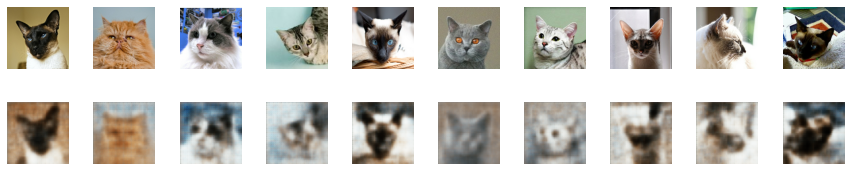

In [36]:
# Chemin du modèle sauvegardé
model_name = "catGeneratingVAE.keras"
model_path = os.path.join(model_dir, model_name)

# Recharger le modèle avec les objets personnalisés nécessaires
vae = tf.keras.models.load_model(
    model_path,
    custom_objects={
        "KLLossLayer": KLLossLayer,
        "sampling": sampling,
        "r_loss": r_loss,
        "total_loss": total_loss
    }
)


show_images(vae)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


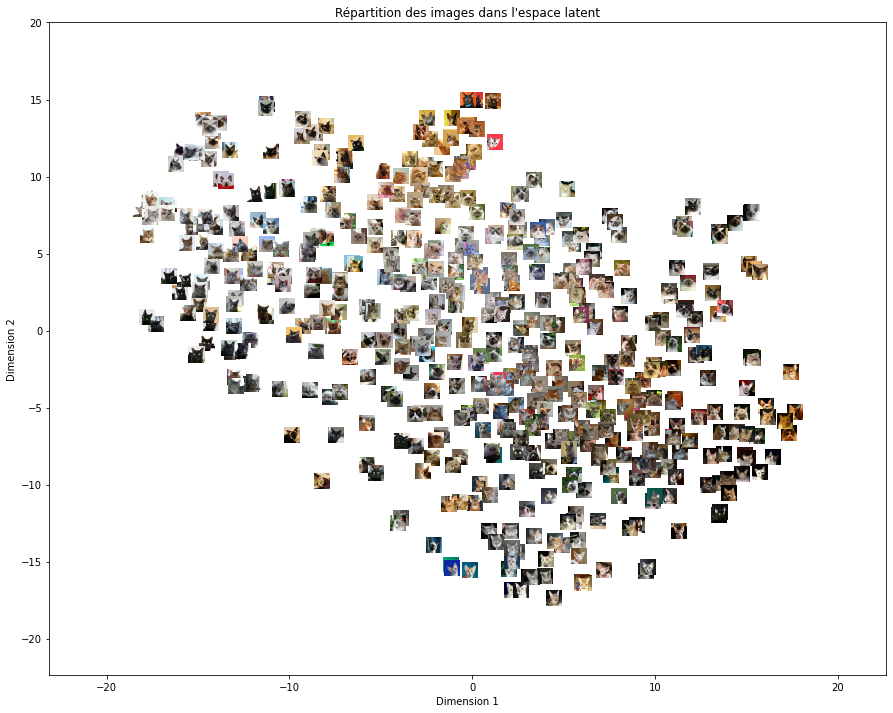

In [38]:
# Chargement du variational autoencodeur
# Chemin du modèle sauvegardé
model_name = "catGeneratingVAE.keras"
# Chargement du modèle VAE avec les objets personnalisés
vae_model_path = os.path.join(model_dir, model_name)
vae = load_model(
    vae_model_path,
    custom_objects={
        "KLLossLayer": KLLossLayer,
        "sampling": sampling,
        "r_loss": r_loss,
        "total_loss": total_loss
    }
)

# Visualisation de l’espace latent du VAE
visualize_latent_space(
    encoder_model=vae_encoder,
    images=example_batch,
    num_images=batch_size,
    image_size=(32, 32),
    zoom=0.5
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


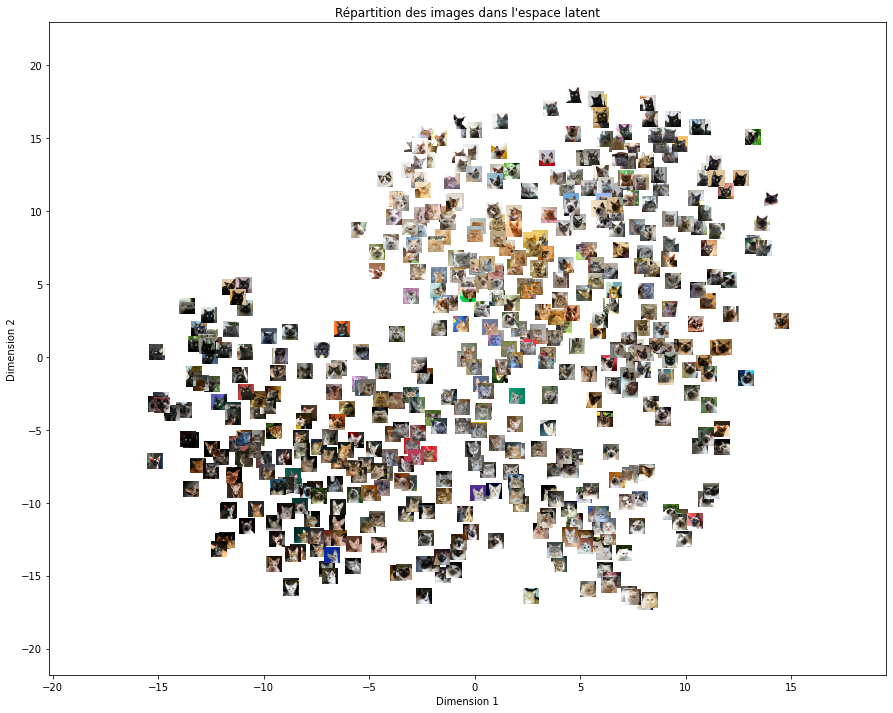

In [39]:
#comparaison avec autoencodeur sans VAE:
# Chemin vers le modèle entraîné
model_path = os.path.join(model_dir, "catmodeltrain.keras")

# Chargement du modèle
autoencoder = load_model(model_path)

# Récupération du premier lot d'images
example_batch = next(data_flow)

# Extraction des images
example_batch = example_batch[0]
# Visualisation de l'espace latent avec les vignettes
visualize_latent_space(
    encoder_model=encoder,
    images=example_batch,
    num_images=batch_size,
    image_size=(32, 32),
    zoom=0.5
)

In [40]:
##idk if theres much difference??? 
#celle de VAE semble un peu plus compacte? 

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


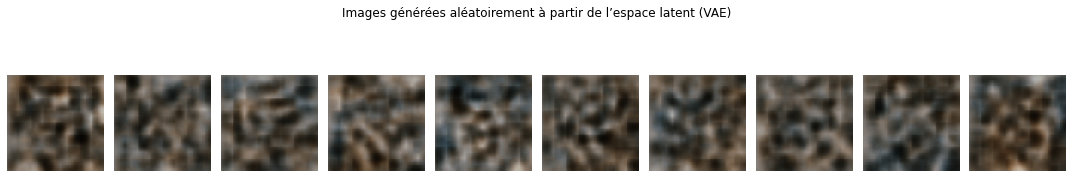

In [41]:
# Chemin du modèle sauvegardé
model_name = "catGeneratingVAE.keras"
# Chargement du modèle VAE avec les objets personnalisés
vae_model_path = os.path.join(model_dir, model_name)
vae = load_model(
    vae_model_path,
    custom_objects={
        "KLLossLayer": KLLossLayer,
        "sampling": sampling,
        "r_loss": r_loss,
        "total_loss": total_loss
    }
)

_ = vae.predict(example_batch)  # passe des images pour activer le modèle

# Nombre d’images à générer
num_images = 10

# Tirage aléatoire de vecteurs latents depuis une normale centrée réduite
latent_vectors = np.random.normal(loc=0.0, scale=1, size=(num_images,
                                                            latent_dim))

vae_decoder = vae.get_layer('decoder')

# Génération des images à partir du décodeur du VAE
generated_images = vae_decoder.predict(latent_vectors)

# Affichage des images générées
plt.figure(figsize=(15, 3))
for i in range(num_images):
    ax = plt.subplot(1, num_images, i + 1)
    plt.imshow(generated_images[i])
    plt.axis("off")

plt.suptitle("Images générées aléatoirement à partir de l’espace latent (VAE)")
plt.tight_layout()
plt.show()

In [42]:
#c'est normal d'avoir ce résultat vu que le tirage des points était aléatoire

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


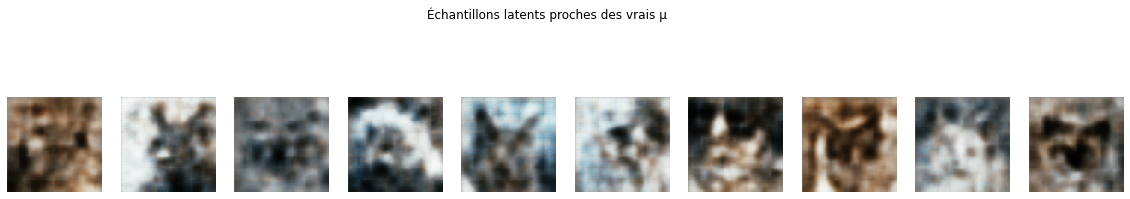

In [43]:
# Sous-modèle pour obtenir les μ
encoder_mu_model = Model(inputs=vae.input,
                         outputs=vae.get_layer('mu').output)

# Obtenir les μ
mus = encoder_mu_model.predict(example_batch)

# Tirage aléatoire autour des μ
epsilon = np.random.normal(size=mus.shape)
scale = 1
latent_samples = mus + scale * epsilon

# Génération d’images à partir du décodeur
vae_decoder = vae.get_layer('decoder')
generated_images = vae_decoder.predict(latent_samples)

# Affichage
plt.figure(figsize=(20, 4))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(generated_images[i])
    plt.axis("off")
plt.suptitle("Échantillons latents proches des vrais μ")
plt.show()

In [ ]:
#deja des résultats bcp mieux! 